[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RlNZLER/Reinforcement-Learning/blob/main/minor_projects/chapter-2-bandit/ucb_action_selection_demo.ipynb)


# Upper Confidence Bound (UCB) Action Selection — 10-Armed Testbed

Demonstrates UCB vs greedy and ε-greedy. UCB chooses:
\[ A_t = \arg\max_a \big[ Q_t(a) + c \sqrt{\tfrac{\ln t}{N_t(a)}} \big]. \]


In [16]:

import numpy as np
import matplotlib.pyplot as plt

N_ACTIONS = 10
N_STEPS = 3000
N_RUNS = 120
CS = [0.5, 1.0, 2.0]
EPSILONS = [0.0, 0.1]


In [17]:

def select_ucb(Q, N, t, c, rng):
    untried = np.where(N == 0)[0]
    if untried.size > 0:
        return rng.choice(untried)
    bonus = c * np.sqrt(np.log(max(1, t)) / N)
    ucb = Q + bonus
    max_val = np.max(ucb)
    return rng.choice(np.flatnonzero(np.isclose(ucb, max_val)))

def select_eps_greedy(Q, epsilon, rng):
    if rng.random() < epsilon:
        return rng.integers(len(Q))
    max_val = np.max(Q)
    return rng.choice(np.flatnonzero(np.isclose(Q, max_val)))

def simulate(method="ucb", c=2.0, epsilon=0.1, n_actions=N_ACTIONS, n_steps=N_STEPS, n_runs=N_RUNS, seed=0):
    rng = np.random.default_rng(seed)
    avg_rewards = np.zeros(n_steps)
    pct_optimal = np.zeros(n_steps)

    for run in range(n_runs):
        q_true = rng.normal(0.0, 1.0, size=n_actions)
        optimal = int(np.argmax(q_true))

        Q = np.zeros(n_actions)
        N = np.zeros(n_actions, dtype=int)

        for t in range(1, n_steps + 1):
            if method == "ucb":
                a = select_ucb(Q, N, t, c, rng)
            elif method == "epsilon":
                a = select_eps_greedy(Q, epsilon, rng)
            elif method == "greedy":
                a = select_eps_greedy(Q, 0.0, rng)
            else:
                raise ValueError("Unknown method")

            r = rng.normal(q_true[a], 1.0)

            N[a] += 1
            Q[a] += (r - Q[a]) / N[a]

            avg_rewards[t-1] += r
            if a == optimal:
                pct_optimal[t-1] += 1

    avg_rewards /= n_runs
    pct_optimal = pct_optimal / n_runs * 100.0
    return avg_rewards, pct_optimal


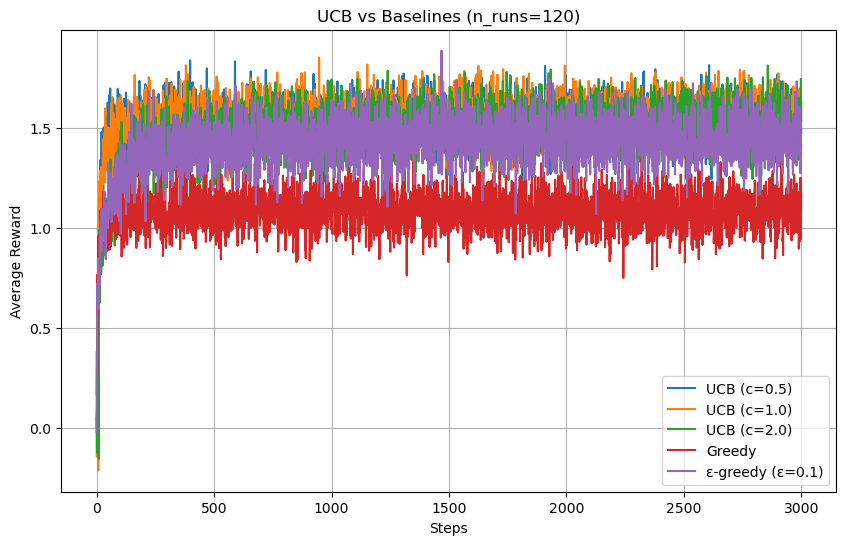

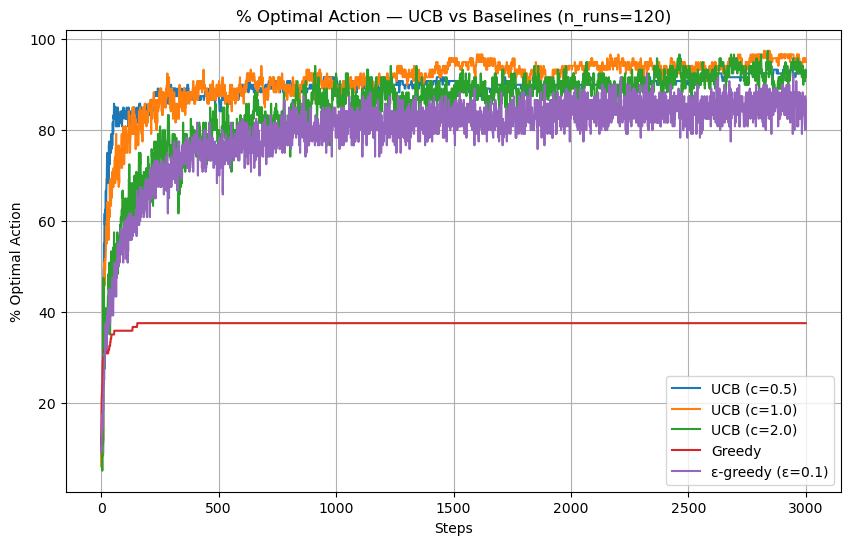

In [18]:

results_ucb = {c: simulate(method="ucb", c=c) for c in CS}
results_baselines = {}
for eps in EPSILONS:
    m = "greedy" if eps == 0.0 else "epsilon"
    results_baselines[m, eps] = simulate(method=m, epsilon=eps)

plt.figure(figsize=(10,6))
for c in CS:
    plt.plot(results_ucb[c][0], label=f"UCB (c={c})")
for (m, eps), (ar, _) in results_baselines.items():
    label = "Greedy" if m == "greedy" else f"ε-greedy (ε={eps})"
    plt.plot(ar, label=label)
plt.xlabel("Steps"); plt.ylabel("Average Reward"); plt.title(f"UCB vs Baselines (n_runs={N_RUNS})")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(10,6))
for c in CS:
    plt.plot(results_ucb[c][1], label=f"UCB (c={c})")
for (m, eps), (_, po) in results_baselines.items():
    label = "Greedy" if m == "greedy" else f"ε-greedy (ε={eps})"
    plt.plot(po, label=label)
plt.xlabel("Steps"); plt.ylabel("% Optimal Action"); plt.title(f"% Optimal Action — UCB vs Baselines (n_runs={N_RUNS})")
plt.grid(True); plt.legend(); plt.show()
